## Para esta tarea voy a cargar el dataset para CIFAR y voy a correr 3 arquitecturas diferentes de redes neuronales

**imports**

In [ ]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

**CUDA**

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

**Cargamos dataset y pasamos a dataloaders**

In [10]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

batch_size = 32

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # A parte de pasar a tensores normalizamos, no nos pide la actividad pero quiero hacerlo
])

train_data = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [4]:
print(len(train_data))
print(len(test_data))

50000
10000


In [12]:
# Definimos nuestras variables que usaremos para las funciones de entrenar

IMG_CHANNELS = 3
IMG_HEIGHT = 32
IMG_WIDTH = 32

**Funcion de entrenamiento**


In [13]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [18]:
def train(_model, _train_loader, _test_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }

    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        # ===== TRAIN =====
        _model.train()
        train_loss = 0.0
        train_acc = 0.0

        for X_batch, y_batch in _train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        # ===== TEST =====
        _model.eval()
        test_loss = 0.0
        test_acc = 0.0

        with torch.no_grad():
            for X_test, y_test in _test_loader:
                X_test = X_test.to(device)
                y_test = y_test.to(device)

                test_outputs = _model(X_test)
                loss = _criterion(test_outputs, y_test)

                test_loss += loss.item() * X_test.size(0)
                test_acc += get_batch_accuracy(test_outputs, y_test, len(_test_loader.dataset))

        epoch_test_loss = test_loss / len(_test_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",
            test_acc=f"{test_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['test_loss'].append(epoch_test_loss)
        res['test_acc'].append(test_acc)

    return res

**Funcion de evalaucion de la red neuronal usando test, NO es necesaria por la indicacion de la tarea**

**Funcion para imprimir los plots (Loss curves y Acc curves)**

In [29]:
import matplotlib.pyplot as plt

def plot_learning_curves(train_history):
    epochs = range(1, len(train_history['train_loss']) + 1)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, train_history['train_loss'], label='Train Loss')
    plt.plot(epochs, train_history['test_loss'], label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Curvas de pérdida')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, train_history['train_acc'], label='Train Accuracy')
    plt.plot(epochs, train_history['test_acc'], label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Curvas de accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

**Definimos 3 arquitecturas para las CNNs**

Ya pregunte al profe y podemos usar nn.Sequential en vez de class convolution y referenciarlo 

**Primer arquitectura de CNN**

In [20]:
model_cnn1 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # Aplicamos 25 filtros 3x3 stride 1, padding 1. Baseline
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # Reducimos imagen a la mitad

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # Ahora entran 25 canales por eso salio la layer pasada, output ahora con 50, porque uso 50 kernels
    nn.ReLU(),
    nn.Dropout(.2), # Para prevenir overfitting
    nn.MaxPool2d(2, stride=2),  

    nn.Conv2d(50, 75, 3, stride=1, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  

    nn.Conv2d(75, 100, 3, stride=1, padding=1), 
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  

    nn.Flatten(),
    nn.Linear(100 * 2 * 2, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 10) # 10 clases para CIFAR
)

model_cnn1 = model_cnn1.to(device)

In [22]:
epochs = 20
loss_function = nn.CrossEntropyLoss() # Esta es nuestra funcion de perdida apropiada al problema ya que es para clasificacion multiclase
optimizer = Adam(model_cnn1.parameters()) # Utilizaremos el optimizador Adam

cnn_res = train(model_cnn1, train_loader, test_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [03:49<00:00, 11.47s/epoch, test_acc=0.7582, test_loss=0.7473, train_acc=0.8483, train_loss=0.4288]


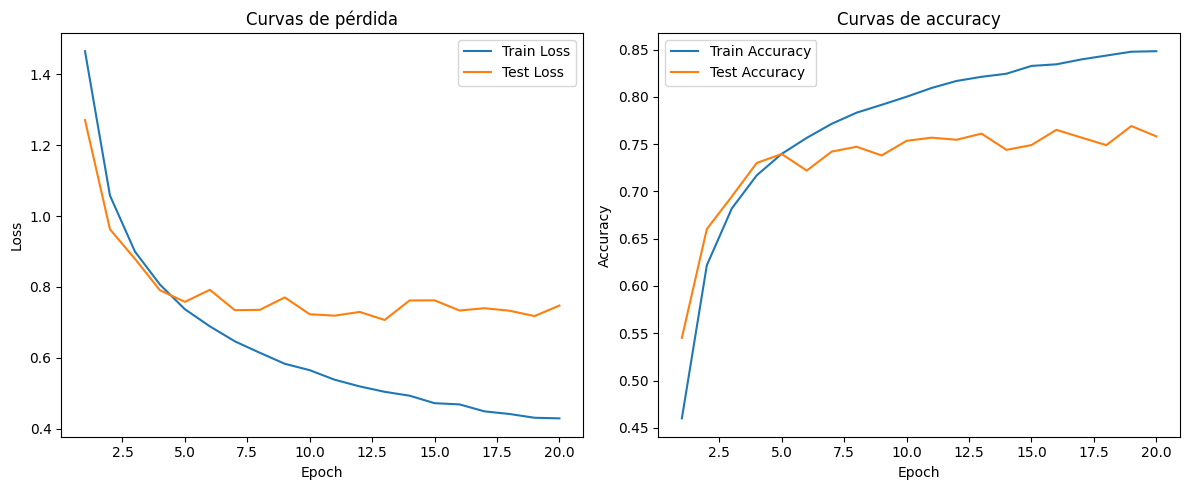

In [30]:
plot_learning_curves(cnn_res)

### **Remarks 1ra arquitectura**

Nos fue masomenos, tenemos un test acc de 0.75 y el train alcanza los 0.85 entonces sugiere que hay overfitting, y las curvas de perdida sugieren lo mismo, en si es un buen funcionamiento el de la red neuronal pero creo que se puede mejorar porque hay overfitting

**Segunda arquitectura**

Esta la vamos a definir con el class convolution para probar otra manera de implementar la CNN aunque es la que menos me gusta

In [23]:
class ConvolutionalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p):
        super().__init__()
        kernel_size = 3

        self.model = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.MaxPool2d(2, stride=2)
        )

    def forward(self, x):
        return self.model(x)

In [26]:
# Se viene una red neuronal pesada jaja
model_cnn2 = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0), 
    ConvolutionalBlock(25, 50, 0.2),  
    ConvolutionalBlock(50, 75, 0), 
    ConvolutionalBlock(75, 100, 0),  
    ConvolutionalBlock(100, 500, 0),     

    nn.Flatten(),
    nn.Linear(500 * 1 * 1, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 250),
    nn.ReLU(),
    nn.Linear(250, 100),
    nn.ReLU(),
    nn.Linear(100, 10)
)

model_cnn2 = model_cnn2.to(device)

In [27]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn2.parameters())

cnn_res2 = train(model_cnn2, train_loader, test_loader, loss_function, optimizer, epochs)


Training: 100%|██████████| 20/20 [03:48<00:00, 11.43s/epoch, test_acc=0.7416, test_loss=0.9428, train_acc=0.9002, train_loss=0.2983]


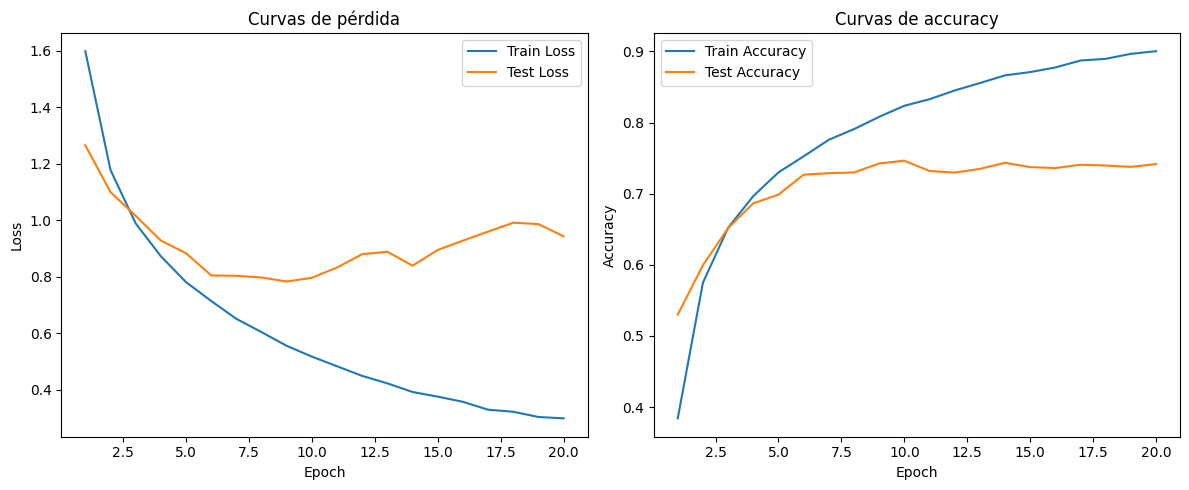

In [31]:
plot_learning_curves(cnn_res2)

### **Remarks 2nda arquitectura**

Hubo muchoo overfitting, pareciera que le fue mejor que la primera porque subio hasta .9 el acc pero en realidad fue training, el test acc quedo igual e incluso peor entonces le fue mal a este modelo tan pesado que era lo esperado ya que este dataset esta sumamente sencillo

**3ra arquitectura**

Para la tercera arquitectura voy a probar un modelo mas ligero, menos kernels, menos layers, etc. Para ver si podemos quitar el overfitting pero mas importante mejorar el rendimiento en test de la red neuronal

In [40]:
model_cnn3 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 16, kernel_size=3, stride=1, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                                        

    nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),           
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                                         

    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),            
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.MaxPool2d(2, stride=2),                                        

    nn.Flatten(),
    nn.Linear(64 * 4 * 4, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 10)
)

model_cnn3 = model_cnn3.to(device)

In [41]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn3.parameters())

cnn_res_light1 = train(model_cnn3, train_loader, test_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [04:09<00:00, 12.49s/epoch, test_acc=0.7504, test_loss=0.7215, train_acc=0.7906, train_loss=0.5852]


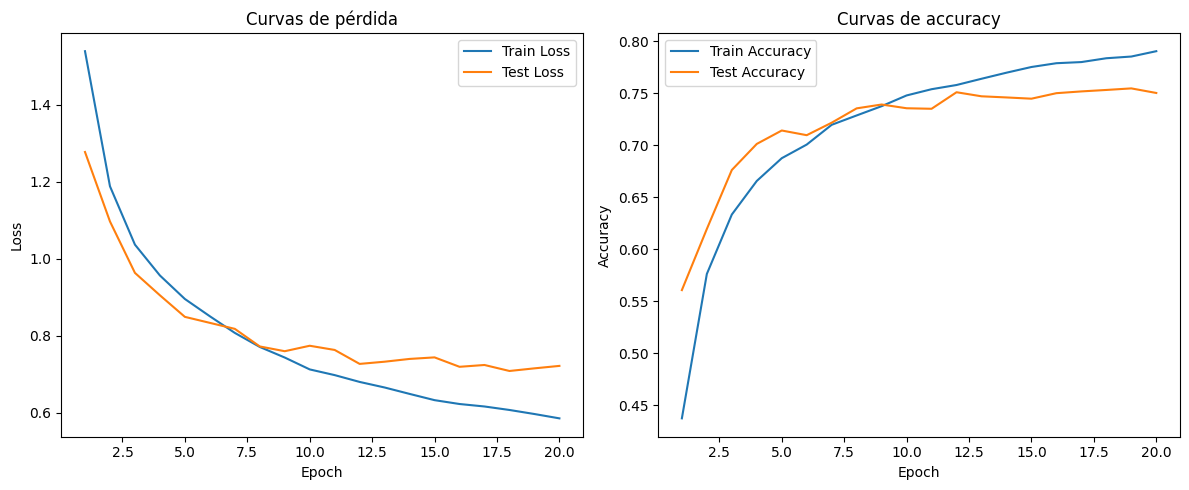

In [42]:
plot_learning_curves(cnn_res_light1)

### **3rd arquitectura remarks**

Bueno definitivamente el overfitting ya mejoro muchisimo, pero a que costo jaja, nos fue peor que en las otras 2 arquitecturas, oseas si, no tenemos overfitting pero ahora el test accuracy esta below 0.75 entonces no supero a la mejor arquitectura


**4th arquitectura**

Correre una cuarta arquitectura mas super ligera solo para ver

In [ ]:
model_cnn4 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 16, kernel_size=3, stride=1, padding=1),  
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                                         

    nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),            
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                                        

    nn.Flatten(),
    nn.Linear(32 * 8 * 8, 64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, 10)
)

model_cnn4 = model_cnn4.to(device)

In [37]:
eepochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn4.parameters())

cnn_res_light = train(model_cnn4, train_loader, test_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [03:40<00:00, 11.01s/epoch, test_acc=0.6897, test_loss=1.0191, train_acc=0.7970, train_loss=0.5484]


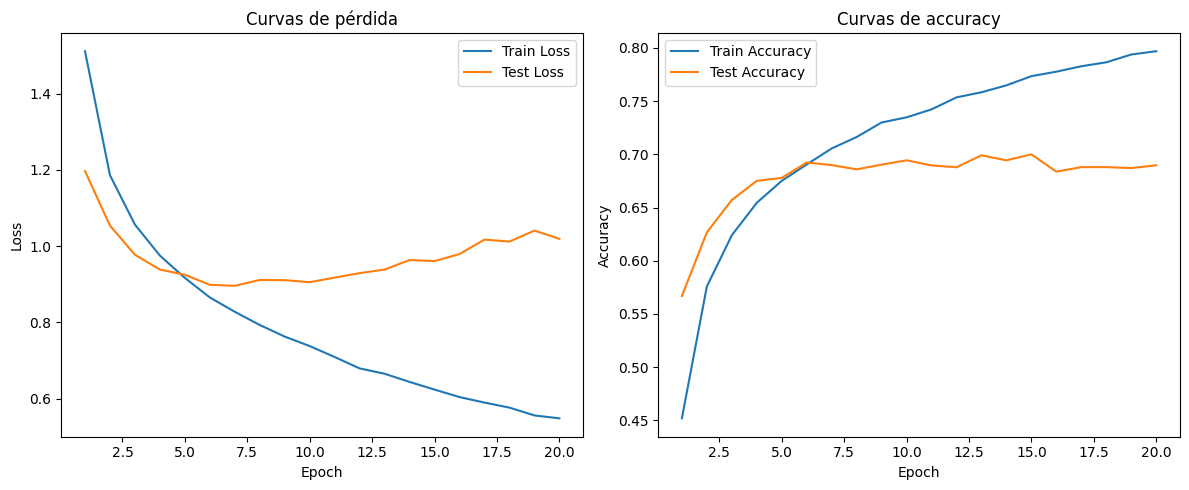

In [38]:
plot_learning_curves(cnn_res_light)

**4th arquitectura remarks**

Pues aunque fue super ligera entre comillas, aun asi tardo lo mismo en entrenarse o muy similar a las otras 3 jajaja, hubo mucho overfitting, de verdad contrario a lo que se pensaba tener la arquitectura tan ligera pues hubo mucho overfitting jajaj o no se si sea underfitting porque le fue super mal verdad en Acc. Pero pues al final del dia es overfitting porque test acc esta en los 0.7 y train acc en los 0.8 entonces nos fue mal con este modelo, nos fuimos muy ligero a lo extremo

**Test acc de todos para checar cual fue el mejor**

In [43]:
print(f"Modelo 1 - Test Accuracy final: {cnn_res['test_acc'][-1]*100:.2f}%")
print(f"Modelo 2 - Test Accuracy final: {cnn_res2['test_acc'][-1]*100:.2f}%")
print(f"Modelo 3 - Test Accuracy final: {cnn_res_light1['test_acc'][-1]*100:.2f}%")
print(f"Modelo 4 - Test Accuracy final: {cnn_res_light['test_acc'][-1]*100:.2f}%")

Modelo 1 - Test Accuracy final: 75.82%
Modelo 2 - Test Accuracy final: 74.16%
Modelo 3 - Test Accuracy final: 75.04%
Modelo 4 - Test Accuracy final: 68.97%


**Corremos el mejor modelo pero evaluandolo**

In [44]:
def test(_model, _test_loader, _criterion):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0

    with torch.no_grad():
        for X_test, y_test in _test_loader:
            X_test = X_test.to(device)
            y_test = y_test.to(device)

            outputs = _model(X_test)
            loss = _criterion(outputs, y_test)

            test_loss += loss.item() * X_test.size(0)
            test_acc += get_batch_accuracy(outputs, y_test, len(_test_loader.dataset))

    epoch_test_loss = test_loss / len(_test_loader.dataset)
    return epoch_test_loss, test_acc

In [45]:
best_test_loss, best_test_acc = test(model_cnn1, test_loader, loss_function)

print(f"Mejor modelo: Modelo 1")
print(f"Test Accuracy final: {best_test_acc*100:.2f}%")
print(f"Test Loss final: {best_test_loss:.4f}")

Mejor modelo: Modelo 1
Test Accuracy final: 75.82%
Test Loss final: 0.7473


# **Final Remarks**

Bueno esta actividad me gusto mucho porque me permitio basicamente experimentar entre diferentes arquitecturas de redes neuronales, supongo que si agarro una CNN con transfer learning nos va a ir mejor pero ese no era el chiste de la actividad. Lo que puede decir es que no me gusto el rendimiento porque nisiquiera alcanzamos el 0.8 en test acc jaja supongo que hay muchas mas cosas que pudieramos hacer pero para el objetivo de la actividad ya se probaron 3 hasta 4 arquitecturas diferentes y las benchmarkeamos, entonces se cumplio el objetivo

Tambien algo que aprendi es que mas no siempre es mejor, no importa si pones muchas layers, muchas convoluciones, etc. Si el problema no lo requiere al final del dia puede que termines haciendo overfitting y nisiquiera vas a aprovechar al 100% esos layers tan pesados de la CNN, mejor primero evalua el problema que tienes enfrente

Tambien despues de correr la evaluacion en test quedo igual o similar entonces esta bien, sabiendo los 4 test accs de los modelos podemos inferir en que no siempre mucho es lo mejor (2ndo modelo) y no siempre poquito es lo mejor (4to modelo). Dependera del problema especifico